# Final Project: Do you have (spotifiy and) good taste in music?

My goal for this project is to gather get data from my spotify playlist create an algorithm classifies my music so I know what I like. This will hopefully make it easier to find new music as I can just run my algorithm on another playlist which will show me songs I'm more likely to enjoy.

The goal is to create a tutorial that walks the reader through the Data Science pipeline.
'The Data Science pipeline' conists of:
1. Data collection/curation + parsing (if necessary)
2. Data management/representation
3. Exploratory data analysis
4. Hypothesis testing
5. Communication of insights attained

## Data Colection
First we need to colect our music from spotify. Luckly, there is an API called spotipy to help me with that. All it need is a Client ID and a Client Secret. Those are your access tokens so that you can see music from your private playlist. You can read more about Spotipy <a href="https://google.at">here</a>.

#### Client ID and Client Secret

To get our Client ID and Client Secret, you need to create a new app in your spotify dashboard. To do so, go to <a href="https://developer.spotify.com/dashboard/">your Dashboard</a>, login and click 'create an app'. Enter an App Name and App Description of your choice (they will be displayed to the user on the grant screen), put a tick in the Developer Terms of Service checkbox and finally click on 'create'. Your application is now registered, and you’ll be redirected to the app overview page.

Now we should be good to go! We can import spotipy

In [1]:
#!pip3 install spotipy
#!pip3 install xgboost
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings


Now we have enough information to login and access our playlist.

In [2]:
user = open("cid.txt", "r").read()
pswd = open("secret.txt", "r").read()

cid = user
secret = pswd

client_credentials_manager = SpotifyClientCredentials(client_id=cid, client_secret=secret)
sp = spotipy.Spotify(client_credentials_manager = client_credentials_manager)                                              

This function gets the music from a playlist and its metadata and puts it in a DataFrame.
These are the kinds of features we can extract from the output.

    Metainformation (Artist, Album, Track Name, Track ID)
    Acoustic Parameters (Loudness, Key, Mode, Tempo)
    Psychoacoustic Parameters (Danceability, Energy, Instrumentalness, Liveness, Valence)

In [3]:
def call_playlist(creator, playlist_id):
    playlist_features_list = ["artist","album","track_name","track_id","danceability","energy","key","loudness","mode", "speechiness","instrumentalness","liveness","valence","tempo", "duration_ms","time_signature"]
    playlist_df = pd.DataFrame(columns = playlist_features_list)
    
    # returns javacript
    playlist = sp.user_playlist_tracks(creator, playlist_id)["items"]
    for track in playlist:
        # Create empty dict
        playlist_features = {}
        # Get metadata
        playlist_features["artist"] = track["track"]["album"]["artists"][0]["name"]
        playlist_features["album"] = track["track"]["album"]["name"]
        playlist_features["track_name"] = track["track"]["name"]
        playlist_features["track_id"] = track["track"]["id"]
        
        # Get audio features
        audio_features = sp.audio_features(playlist_features["track_id"])[0]
        for feature in playlist_features_list[4:]:
            playlist_features[feature] = audio_features[feature]
        
        # Concat the dfs
        track_df = pd.DataFrame(playlist_features, index = [0])
        playlist_df = pd.concat([playlist_df, track_df], ignore_index = True)

    return playlist_df

In [14]:
# This is how i would get music from a playlist
your_music = call_playlist("spotify","7vI0tN3yUn07dkK9T6p2pg")
your_music.head()

,artist,album,track_name,track_id,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Manuel Turizo,La Bachata,La Bachata,5ww2BF9slyYgNOk37BlC4u,0.835,0.679,7,-5.329,0,0.0364,0.000002,0.2180,0.850,124.980,162638,4
1,Arcángel,SR. SANTOS,La Jumpa,2mnXxnrX5vCGolNkaFvVeM,0.887,0.234,9,-14.520,1,0.1780,0.670000,0.1300,0.197,140.020,196800,4
2,Bad Bunny,Un Verano Sin Ti,Me Porto Bonito,6Sq7ltF9Qa7SNFBsV5Cogx,0.911,0.712,1,-5.105,0,0.0817,0.000027,0.0933,0.425,92.005,178567,4
3,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,1IHWl5LamUGEuP4ozKQSXZ,0.650,0.715,5,-5.198,0,0.2530,0.000291,0.1260,0.187,106.672,243717,4
4,Ozuna,OzuTochi,Hey Mor,1zsPaEkglFvxjAhrM8yhpr,0.901,0.589,1,-6.713,0,0.2890,0.000237,0.0992,0.399,98.002,196600,4


Now let's get it from my playlist!
Go to the webpage of the playlist you want and copy this portion of the URL:

        Example playlist URL: https://open.spotify.com/playlist/5EI6wYUrYSOfClAsoZPcsl
        PLaylist_id: 5EI6wYUrYSOfClAsoZPcsl

In [5]:
# here's a playlist i listen to all the time
my_music = call_playlist("28riya", "5EI6wYUrYSOfClAsoZPcsl")
my_music.head()

,artist,album,track_name,track_id,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Royaljag,909,909,6glgMASW5SQmWN2LcBj8K9,0.675,0.678,11,-7.225,0,0.0252,0.000633,0.1540,0.616,105.971,235583,4
1,Private Island,Enough,Enough,6lPEFFYn6RShLTL8WGiDW6,0.552,0.878,5,-6.195,1,0.0558,0.005750,0.1690,0.375,102.015,261525,4
2,Skylar Spence,Prom King,Fiona Coyne,6XkEIIZs0oMUNwaVwHXSZ0,0.659,0.853,2,-5.617,1,0.1360,0.000015,0.3270,0.651,110.011,249320,4
3,Magdalena Bay,Neon,Neon,1wN1fHF00XgdQzFcD34gnl,0.598,0.635,4,-7.607,0,0.0287,0.025600,0.0773,0.606,90.010,152761,4
4,Berhana,Wildin',Wildin',4LGg2NY9eHp0jF3L1WbCNl,0.760,0.480,1,-8.535,0,0.2260,0.000000,0.7170,0.877,90.010,139613,4


Here's a peek:

In [6]:
print(my_music.dtypes)

artist               object
album                object
track_name           object
track_id             object
danceability        float64
energy              float64
key                  object
loudness            float64
mode                 object
speechiness         float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms          object
time_signature       object
dtype: object


In [7]:
# changing types of key, mode, duration_ms, time_signature
my_music['key'] = my_music['key'].astype('float64')
my_music['mode'] = my_music['mode'].astype('float')
my_music['duration_ms'] = my_music['duration_ms'].astype('float64')
my_music['time_signature'] = my_music['time_signature'].astype('float64')
print(my_music.dtypes)

artist               object
album                object
track_name           object
track_id             object
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms         float64
time_signature      float64
dtype: object


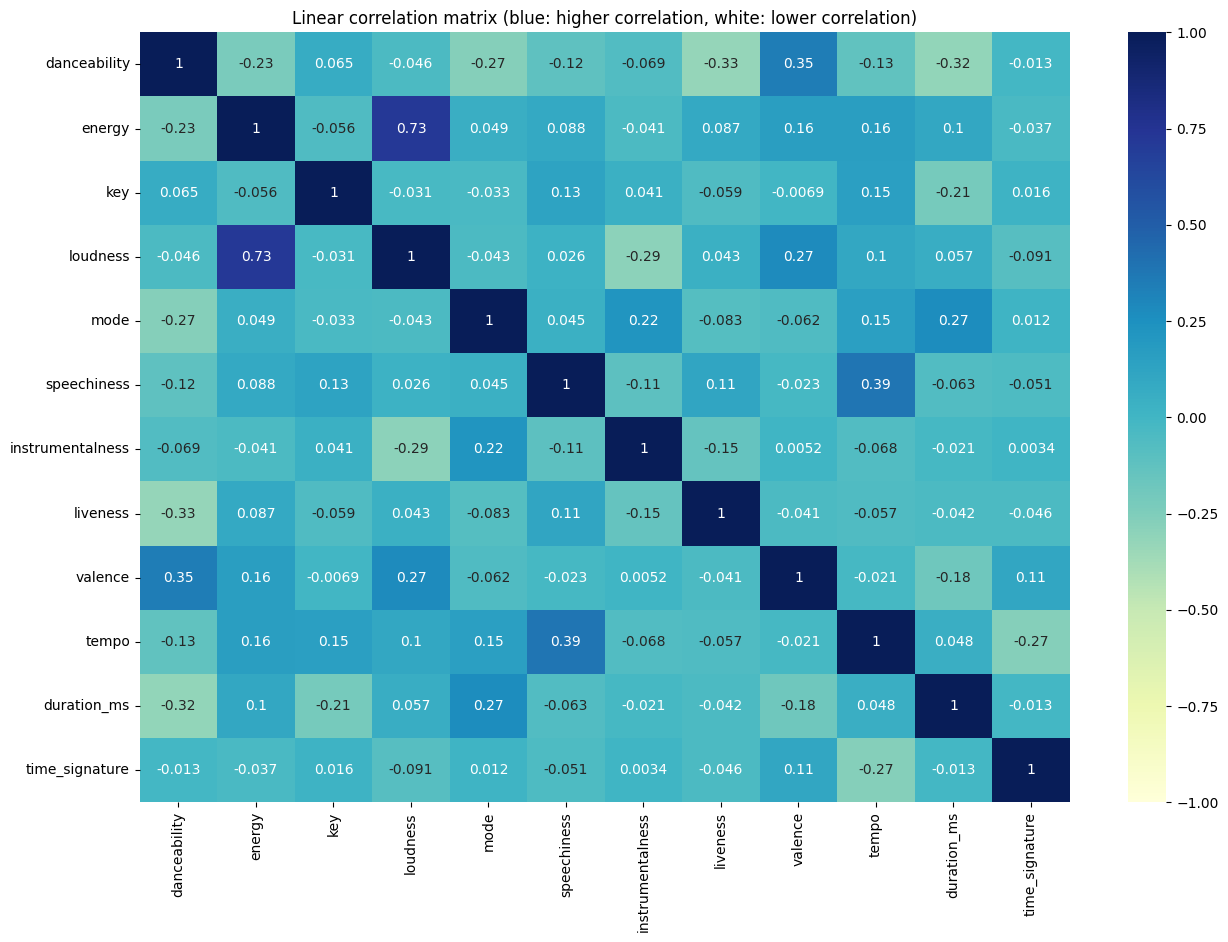

In [8]:
# Plot linear correlation matrix
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(my_music[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']].corr(), annot=True, cmap='YlGnBu', vmin=-1, vmax=1, center=0, ax=ax)
plt.title('Linear correlation matrix (blue: higher correlation, white: lower correlation)')
plt.show()

Nice! we see some correlation. That makes it easier for our algorithm.
I think i like calm songs. Is that true?

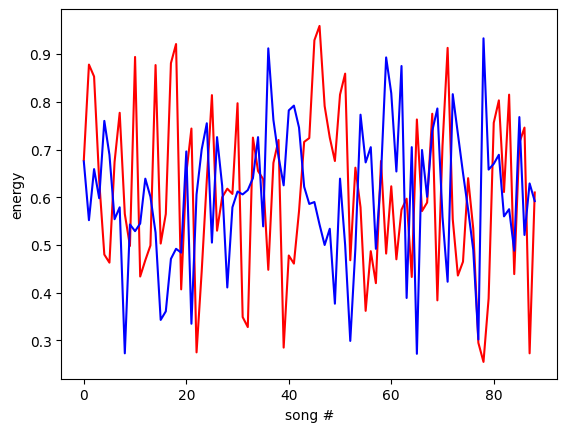

In [9]:
x = my_music.index
y1 = my_music['energy']
plt.plot(x,y1,'r')
y2 = my_music['danceability']
plt.plot(x,y2,'b')
plt.ylabel('energy')
plt.xlabel('song #')
plt.show()

I guess not...

Getting rid of metadata columns and keeping
Acoustic Parameters (Loudness, Key, Mode, Tempo)
Psychoacoustic Parameters (Danceability, Energy, Instrumentalness, Liveness, Valence)

In [10]:
warnings.filterwarnings('ignore')
my_music = my_music[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']]


In [11]:
print(*my_music.columns)

danceability energy key loudness mode speechiness instrumentalness liveness valence tempo duration_ms time_signature


In [12]:
warnings.filterwarnings('ignore')
# here are te features i care about.
my_music = my_music[['key', 'mode', 'tempo']]

# create train_test_split
from sklearn.model_selection import train_test_split
X = my_music
y = my_music.index
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30, shuffle=True)

# classifies
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7,p=2,metric='euclidean')
knn.fit(X_train, y_train)

# prediction
prediction = knn.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       1.0
           6       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       1.0
           9       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       1.0
          11       0.00      0.00      0.00       0.0
          13       0.00      0.00      0.00       0.0
          14       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       0.0
          18       0.00      0.00      0.00       0.0
          21       0.00      0.00      0.00       1.0
          24       0.00      0.00      0.00       1.0
          26       0.00      0.00      0.00       0.0
          28       0.00    

In [15]:
# now you should be able to just put your playlist here and it should tell if our taste is similar:
#name = "name"
#uri = "uri"
#your_music = call_playlist(name, uri)

# changing types of key, mode, duration_ms, time_signature
your_music['key'] = your_music['key'].astype('float64')
your_music['mode'] = your_music['mode'].astype('float')
your_music['duration_ms'] = your_music['duration_ms'].astype('float64')
your_music['time_signature'] = your_music['time_signature'].astype('float64')

# here are te features i care about
your_music = your_music[['key', 'mode', 'tempo']]

# create train_test_split
from sklearn.model_selection import train_test_split
X = your_music
y = your_music.index
_, _, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30, shuffle=True)

# prediction
prediction = knn.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))

ValueError: Found input variables with inconsistent numbers of samples: [30, 27]

Its pretty different. That makes sense, that playlist is awful.